In [1]:
import numpy as np
from scipy.sparse.linalg import spsolve
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

from visualise import visualise
from refine import refine
from mu_area import mu_area
from elt_stiffness import elt_stiffness
from global_stiffness import global_stiffness
from rhs import rhs

Start by specifying the domain $\Omega$ by giving the nodes and the elements of an initial (coarse) mesh. 

In [2]:
# Define your nodes and elements here
nodes = np.array([[0.0, 0.0, 1],
                  [1.0, 0.0, 1],
                  [1.0, 1.0, 1],
                  [0.0, 1.0, 1],
                  [0.5798, 0.5986, 0]])  # Interior node (a, b)

# Define your elements with 1-based indexing
elements = np.array([[1, 2, 5],  # Triangle 1
                     [2, 3, 5],  # Triangle 2
                     [3, 4, 5],  # Triangle 3
                     [4, 1, 5]]) # Triangle 4

nnodes, m = nodes.shape


Visualises the nodes and elements of the current mesh.

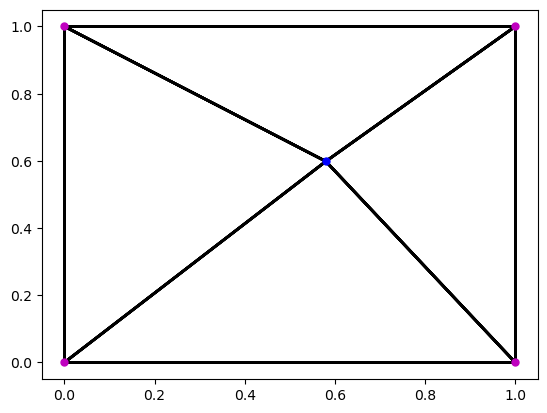

In [5]:
def visualise(nodes, elements):
    nelts, m = elements.shape   # Finds the number of elements

    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    for ie in range(1, nelts + 1):
        plt.plot(nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 0], nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)

    #Plot the nodes on top: use a magenta dot for Dirichlet nodes
    # and a blue dot for non-Dirichlet nodes

    # Find Dirichlet nodes
    ND = np.where(nodes[:, 2] == 1)[0]
    # Plot them
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10)

    # Find non-Dirichlet nodes
    N0 = np.where(nodes[:, 2] != 1)[0]
    # Plot them
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'b.', markersize=10)

    plt.show()

# Example usage:
visualise(nodes, elements)


In [6]:
def visited(edges, node1, node2):
    nedges, m = edges.shape

    for i in range(1, nedges + 1):
        if ((edges[i - 1, 0] == node1 and edges[i - 1, 1] == node2) or
            (edges[i - 1, 0] == node2 and edges[i - 1, 1] == node1)):
            return i

    return 0


In [7]:
def refine(nodes, elements):

    nnodes, m = nodes.shape
    nelts, m = elements.shape

    newnodes = nodes.copy()
    newelements = np.zeros((4*nelts,3))
    inode = 1
    edgetable = np.zeros((0, 2), dtype=int)

    for ie in range(1, nelts + 1):
        newloc = np.zeros(3, dtype=int)

        for edge in range(1, 4):
            n1 = edge
            n2 = (edge % 3) + 1

            newloc[edge - 1] = visited(edgetable,
                                       elements[ie - 1, n1 - 1].astype(int)-1, elements[ie - 1, n2 - 1].astype(int)-1)

            if newloc[edge - 1] == 0:
                newloc[edge - 1] = inode
                inode += 1

                edgetable = np.vstack([edgetable, [elements[ie - 1, n1 - 1].astype(int)-1, elements[ie - 1, n2 - 1].astype(int)-1]])

                temp = np.append((nodes[elements[ie - 1, n1 - 1].astype(int) - 1, :2] +nodes[elements[ie - 1, n2 - 1].astype(int) - 1, :2])/2, 1)
    
                newnodes = np.vstack([newnodes, temp])
                

            else:
                newnodes[nnodes + newloc[edge - 1] - 1, 2] = 0

        newloc += nnodes

        for tau in range(0, 3):
            newelements[4 * (ie - 1) + tau , :3] = [elements[ie - 1, tau].astype(int),
                                                        newloc[tau].astype(int), newloc[((tau+2) % 3)].astype(int)]
            

        newelements[4 * (ie - 1) - 1, :3] = newloc[:3].astype(int)
      

    return newnodes, newelements


Uniformly refine the mesh as many times as specified in `nref`.

In [8]:
nref = 1
for i in range(nref):
    nodes, elements = refine(nodes, elements)

nnodes, m = nodes.shape

Visualise the refined mesh (if not too fine).

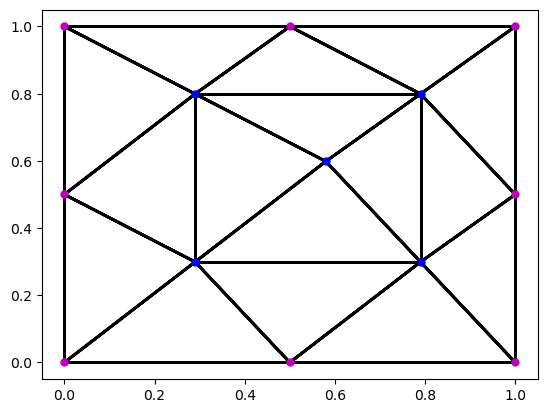

In [9]:
if nnodes < 1000:
    visualise(nodes, elements)

Compute the element stiffness matrices.

In [10]:
# Assuming a and b are defined somewhere earlier in your code:
a, b = 0.5798, 0.5986  # Coordinates of (a, b)

# After refining
newnodes, newelements = refine(nodes, elements)

# Find (a, b) in the new nodes list
ab_index = np.where((np.isclose(newnodes[:, 0], a, atol=1e-4) &
                     np.isclose(newnodes[:, 1], b, atol=1e-4)))[0]

if len(ab_index) == 1:
    print("The interior node (a, b) is at index", ab_index[0], "in the new nodes.")
else:
    print("Error: The interior node (a, b) was not found or duplicated in the new nodes.")

The interior node (a, b) is at index 4 in the new nodes.


In [11]:
# Confirm the coordinates of the new (a, b) node
print("Coordinates of new (a, b):", newnodes[4, :2])


Coordinates of new (a, b): [0.5798 0.5986]


In [12]:
def mu_area(X):
    # Takes three nodes of a triangle, listed as the rows
    # of a matrix X and finds the area of this triangle
    a = np.abs(np.linalg.det(np.column_stack((np.ones(3), X))) / 2)
    return a


In [13]:
def elt_stiffness(elements, nodes):
    nelts, m = elements.shape  # Finds how many elements there are

    elt_matrices = [None] * nelts

    for ie in range(nelts):
        elt_matrices[ie] = np.zeros((3, 3))

        X = nodes[elements[ie].astype(int) - 1, :2]  # Coordinates of 3 nodes of element ie

        area = mu_area(X)  # Area of element ie using the determinant formula from lectures

        E = np.array([X[1, :] - X[2, :], X[2, :] - X[0, :], X[0, :] - X[1, :]])

        # Now we implement the formula given in lectures for the
        # element stiffness matrices corresponding to the Laplacian.

        Atau = np.array([[np.dot(E[0, :], E[0, :]), np.dot(E[0, :], E[1, :]), np.dot(E[0, :], E[2, :])],
                         [np.dot(E[1, :], E[0, :]), np.dot(E[1, :], E[1, :]), np.dot(E[1, :], E[2, :])],
                         [np.dot(E[2, :], E[0, :]), np.dot(E[2, :], E[1, :]), np.dot(E[2, :], E[2, :])]])

        elt_matrices[ie] = Atau / (4 * area)

    return elt_matrices


In [14]:
elt_matrices = elt_stiffness(elements, nodes)

Assemble the global extended stiffness matrix.

In [15]:
from scipy.sparse import coo_matrix, csr_matrix
from scipy import sparse


In [16]:
def global_stiffness(elt_matrices, elements, nodes):
    nelts, m = elements.shape
    nnodes, m = nodes.shape

    # Create an empty sparse matrix with nnodes columns and rows
    Ahat = csr_matrix((nnodes, nnodes), dtype=float) 

    # Assemble the global stiffness matrix from the element matrices
    # including all the boundary nodes
    for ie in range(nelts):
        iglob = elements[ie, :]
        indeces = np.meshgrid(elements[ie, :].astype(int)-1,elements[ie, :].astype(int)-1)
        tempel = sparse.csr_matrix(elt_matrices[ie])
        Ahat[tuple(indeces)] += tempel 

    return Ahat 


In [17]:
Ahat = global_stiffness(elt_matrices, elements, nodes)

/opt/conda/lib/python3.9/site-packages/scipy/sparse/_index.py:134: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)


Select appropriate blocks of $\hat{A}$ to get the stiffness matrix $A$.

In [18]:
N0 = np.where(nodes[:, 2] != 1)[0]
A = Ahat[N0][:, N0]

Define the source term for Poisson's equation.

In [19]:
def source_term(x1, x2):
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))
f_obj = source_term

Compute the load vector.

In [20]:
def rhs(func, N0, elements, nodes):
    nelts, m = elements.shape  # Finds how many elements there are
    nnodes, m = nodes.shape     # Finds how many nodes there are

    fhat = np.zeros(nnodes)      # Initialize with a vector of zeros

    for ie in range(1, nelts + 1):
        X = nodes[elements[ie - 1].astype(int)-1, :2]  # Coordinates of 3 nodes of element ie

        area = mu_area(X)  # Area of element ie

        for p in range(1, 4):
            i = elements[ie - 1, p - 1].astype(int)
            fhat[i - 1] += func(X[p - 1, 0], X[p - 1, 1]) * area / 3

    return fhat[N0] 


In [21]:
f = rhs(f_obj, N0, elements, nodes)

Solve the linear system to get the FEM solution coefficients.

In [22]:
U = spsolve(A, f)

Compute the extended vector $\hat{U}$.

In [23]:
Uhat = np.zeros(nnodes)
Uhat[N0] = U

Plot the FEM solution.

Text(0.5, 0.92, 'Numerical solution')

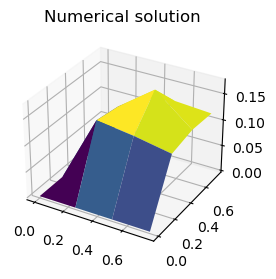

In [24]:
h_unif = 1 / (2 ** (nref + 1)) # to have a regular grid size comparable to the one used for FEM computations
XI, YI = np.meshgrid(np.arange(min(nodes[:, 0]), max(nodes[:, 0]), h_unif),
                     np.arange(min(nodes[:, 1]), max(nodes[:, 1]), h_unif))
ZI = griddata(nodes[:,:2], Uhat, (XI, YI), method='linear')

fig = plt.figure()
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(XI, YI, ZI, cmap='viridis')
ax.set_title('Numerical solution')

Evaluate the exact solution at the nodes.

In [25]:
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)
# Evaluate the exact solution at each node of the initial mesh
exact_at_nodes = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Extract the (a, b) coordinates from the nodes array
# It is the interior node, which should be the last in our nodes list
a, b = nodes[4, :2]

# Compute the exact solution at (a, b)
exact_at_ab = exact_solution(a, b)

# Show the exact solution at nodes and at (a, b)
exact_at_nodes, exact_at_ab

(array([0.        , 0.        , 0.        , 0.        , 0.10453273,
        0.        , 0.07668073, 0.05769106, 0.        , 0.05865494,
        0.        , 0.04412928, 0.        ]),
 0.10453272703389084)

In [26]:
a, b = nodes[4, :2]

# Print the coordinates (a, b)
print("Coordinates of (a, b):", a, b)

Coordinates of (a, b): 0.5798 0.5986


Plot the exact solution.

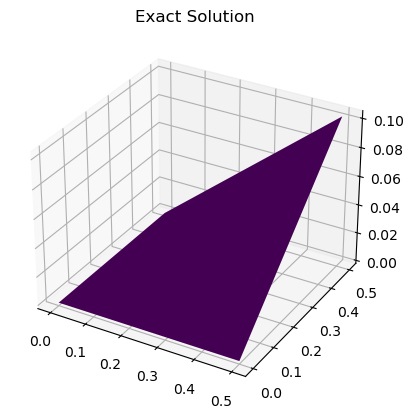

In [27]:
def source_term(x1, x2):
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))

# Define the exact solution given by the user
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Now, let's plot the exact solution on a meshgrid to visualize it
h_unif = 1 / 2  # assuming a coarse grid for visualization
XI, YI = np.meshgrid(np.arange(0, 1, h_unif), np.arange(0, 1, h_unif))
ZI_exact = exact_solution(XI, YI)

# Plotting the exact solution
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XI, YI, ZI_exact, cmap='viridis')
ax.set_title('Exact Solution')

plt.show()

Calculate error at nodes and plot it.

In [28]:
def run_simulation(num_refinements, initial_nodes, initial_elements):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)
    
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    N0 = np.where(nodes[:, 2] != 1)[0]
    A = Ahat[N0][:, N0]
    f = rhs(exact_solution, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    return Uhat, nodes, elements

# Initialize the mesh
initial_nodes = np.array([[0.0, 0.0, 1],
                          [1.0, 0.0, 1],
                          [1.0, 1.0, 1],
                          [0.0, 1.0, 1],
                          [0.5798, 0.5986, 0]])  # Interior node (a, b)

initial_elements = np.array([[1, 2, 5],  # Triangle 1
                             [2, 3, 5],  # Triangle 2
                             [3, 4, 5],  # Triangle 3
                             [4, 1, 5]]) # Triangle 4


# Extract the (a, b) coordinates from the initial nodes array
a, b = initial_nodes[4, :2]

# Define points to evaluate absolute error
points = [(a, b), (0.92, 0.2)]

# Define the number of refinements for each mesh size
num_refinements_list = [1, 2, 3, 4, 5]  # Starts from 1 to represent T_{j,j} for j = 2, 3, 4, 5, 6

# Run the simulation for each mesh size and collect the results
for num_refinements in num_refinements_list:
    Uhat, nodes, elements = run_simulation(num_refinements, initial_nodes, initial_elements)
    # Interpolate the FEM solution at the points of interest
    interpolated_values = griddata(nodes[:, :2], Uhat, np.array(points), method='linear')
    # Evaluate the exact solution at the points of interest
    exact_values = np.array([exact_solution(*pt) for pt in points])
    # Calculate and print the absolute errors at the points (a, b) and (0.92, 0.2)
    errors = np.abs(exact_values - interpolated_values)
    print(f"Mesh refinement level {num_refinements+1}:")
    for pt, error in zip(points, errors):
        print(f"Absolute error at {pt}: {error:.6f}")
    print("-------------------------------------------------------")


Mesh refinement level 2:
Absolute error at (0.5798, 0.5986): 0.099381
Absolute error at (0.92, 0.2): 0.028155
-------------------------------------------------------
Mesh refinement level 3:
Absolute error at (0.5798, 0.5986): 0.099386
Absolute error at (0.92, 0.2): 0.028627
-------------------------------------------------------
Mesh refinement level 4:
Absolute error at (0.5798, 0.5986): 0.099278
Absolute error at (0.92, 0.2): 0.028550
-------------------------------------------------------
Mesh refinement level 5:
Absolute error at (0.5798, 0.5986): 0.099228
Absolute error at (0.92, 0.2): 0.028547
-------------------------------------------------------
Mesh refinement level 6:
Absolute error at (0.5798, 0.5986): 0.099209
Absolute error at (0.92, 0.2): 0.028550
-------------------------------------------------------


In [29]:
def run_simulation(num_refinements, initial_nodes,initial_elements):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)
    
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    N0 = np.where(nodes[:, 2] != 1)[0]
    A = Ahat[N0][:, N0]
    f = rhs(exact_solution, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    return Uhat, nodes, elements

# Initialize the mesh
initial_nodes = np.array([[0.0, 0.0, 1],
                          [1.0, 0.0, 1],
                          [1.0, 1.0, 1],
                          [0.0, 1.0, 1],
                          [0.5798, 0.5986, 0]])  # Interior node (a, b)

initial_elements = np.array([[1, 2, 5],  # Triangle 1
                             [2, 3, 5],  # Triangle 2
                             [3, 4, 5],  # Triangle 3
                             [4, 1, 5]]) # Triangle 4

# Points to evaluate absolute error
points = [(a, b), (0.92, 0.2)]

# Number of refinements for each mesh size
num_refinements_list = [2, 3, 4, 5, 6]

# Run the simulation for each mesh size and collect the results
for num_refinements in num_refinements_list:
    Uhat, nodes, elements = run_simulation(num_refinements, initial_nodes, initial_elements)
    # Interpolate the FEM solution at the points of interest
    interpolated_values = griddata(nodes[:, :2], Uhat, points, method='linear')
    # Evaluate the exact solution at the points of interest
    exact_values = [exact_solution(*pt) for pt in points]
    # Calculate and print the absolute errors at the points (a, b) and (0.92, 0.2)
    errors = np.abs(exact_values - interpolated_values)
    print(f"Mesh refinement level {num_refinements}:")
    for pt, error in zip(points, errors):
        print(f"Absolute error at {pt}: {error:.6f}")
    print("-------------------------------------------------------")


Mesh refinement level 2:
Absolute error at (0.5798, 0.5986): 0.099386
Absolute error at (0.92, 0.2): 0.028627
-------------------------------------------------------
Mesh refinement level 3:
Absolute error at (0.5798, 0.5986): 0.099278
Absolute error at (0.92, 0.2): 0.028550
-------------------------------------------------------
Mesh refinement level 4:
Absolute error at (0.5798, 0.5986): 0.099228
Absolute error at (0.92, 0.2): 0.028547
-------------------------------------------------------
Mesh refinement level 5:
Absolute error at (0.5798, 0.5986): 0.099209
Absolute error at (0.92, 0.2): 0.028550
-------------------------------------------------------
Mesh refinement level 6:
Absolute error at (0.5798, 0.5986): 0.099203
Absolute error at (0.92, 0.2): 0.028549
-------------------------------------------------------


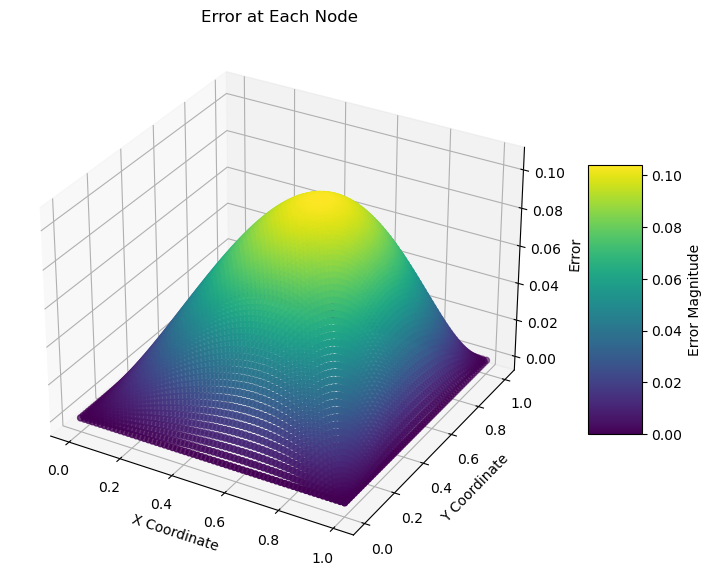

In [30]:
# Define the exact solution function
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Calculate the exact solution at each node
exact_at_nodes = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Calculate the error at each node using Uhat and exact_at_nodes
error_at_nodes = np.abs(exact_at_nodes - Uhat)

# Plot the error at each node
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y coordinates
X, Y = nodes[:, 0], nodes[:, 1]

# Scatter plot for errors
scatter = ax.scatter(X, Y, error_at_nodes, c=error_at_nodes, cmap='viridis', depthshade=True)

# Adding labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Error')
ax.set_title('Error at Each Node')

# Adding a color bar to interpret the error magnitudes
color_bar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
color_bar.set_label('Error Magnitude')

plt.show()

In [39]:
# Provided errors for each mesh refinement level at the two points of interest
errors_at_ab = np.array([0.099386, 0.099278, 0.099228, 0.099209, 0.099203])
errors_at_092_02 = np.array([0.028627, 0.028550, 0.028547, 0.028550, 0.028549])

# Since the mesh size is halved at each refinement, h_j+1 = 0.5 * h_j
# The denominator of the convergence rate formula is log(0.5), which is a constant.
log_half = np.log(0.5)

# Calculate the convergence rates using the formula:
# rate = log(Error_j+1 / Error_j) / log(h_j+1 / h_j)
# We use the errors from one refinement level to the next (hence the use of np.diff)
convergence_rates_ab = np.diff(np.log(errors_at_ab)) / log_half
convergence_rates_092_02 = np.diff(np.log(errors_at_092_02)) / log_half

(convergence_rates_ab, convergence_rates_092_02)

(array([1.56858897e-03, 7.26776557e-04, 2.76271117e-04, 8.72545032e-05]),
 array([ 3.88574375e-03,  1.51604642e-04, -1.51604642e-04,  5.05331106e-05]))

In [33]:
def compute_H1_seminorm_error(U, U_exact, A):
    """
    Compute the H1 semi-norm error between the FEM and exact solutions.

    Parameters:
    U (np.array): The FEM solution vector.
    U_exact (np.array): The exact solution vector.
    A (np.ndarray): The global stiffness matrix.

    Returns:
    float: The H1 semi-norm error.
    """
    difference = U_exact - U
    error_squared = np.dot(difference, A.dot(difference))
    return np.sqrt(error_squared)

# Assuming `N0` contains indices of nodes used in U (interior nodes typically)
U_exact = np.array([exact_solution(nodes[i, 0], nodes[i, 1]) for i in N0])


# Calculate H1 semi-norm error
H1_error = compute_H1_seminorm_error(U, U_exact, A)
print("H1 semi-norm of the error:", H1_error)
print("Size of U:", U.shape)
print("Size of U_exact:", U_exact.shape)


H1 semi-norm of the error: 0.25377348351593926
Size of U: (5,)
Size of U_exact: (5,)


In [34]:
import numpy as np

# Define your initial mesh and elements somewhere above this code
initial_nodes = np.array([[0.0, 0.0, 1],
                          [1.0, 0.0, 1],
                          [1.0, 1.0, 1],
                          [0.0, 1.0, 1],
                          [0.5798, 0.5986, 0]])  # Interior node (a, b)

initial_elements = np.array([[1, 2, 5],  # Triangle 1
                             [2, 3, 5],  # Triangle 2
                             [3, 4, 5],  # Triangle 3
                             [4, 1, 5]]) # Triangle 4

errors = []
mesh_sizes = []

# Perform simulations for each refinement level
for j in range(2, 7):
    Uhat, nodes, elements = run_simulation(j - 1, initial_nodes, initial_elements)
    U_exact = np.array([exact_solution(node[0], node[1]) for node in nodes])
    
    elt_matrices = elt_stiffness(elements, nodes)
    A = global_stiffness(elt_matrices, elements, nodes)
    
    error = compute_H1_seminorm_error(Uhat, U_exact, A)
    errors.append(error)
    mesh_sizes.append(1 / 2 ** (j - 1))  # Assuming h halves with each refinement

# Optionally compute convergence rates
convergence_rates = [np.log(errors[i+1]/errors[i])/np.log(mesh_sizes[i+1]/mesh_sizes[i]) for i in range(len(errors)-1)]

# Print the results in a table format
print("Refinement Level | Mesh Size | H1 Semi-norm Error | Convergence Rate")
print("--------------------------------------------------------------------")
for i in range(len(errors)):
    rate = convergence_rates[i] if i < len(convergence_rates) else None
    print(f"{i+2:16} | {mesh_sizes[i]:10} | {errors[i]:18.6f} | {rate}")



Refinement Level | Mesh Size | H1 Semi-norm Error | Convergence Rate
--------------------------------------------------------------------
               2 |        0.5 |           0.221137 | -0.13282077298284556
               3 |       0.25 |           0.242462 | -0.034634970549858556
               4 |      0.125 |           0.248354 | -0.008645134172141833
               5 |     0.0625 |           0.249846 | -0.002158812371240882
               6 |    0.03125 |           0.250220 | None


Calculate the measure for the error (energy norm).

In [31]:
def run_simulation(num_refinements, initial_nodes, initial_elements):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)

    # Assuming refine updates the nodes and elements correctly
    N0 = np.where(nodes[:, 2] != 1)[0]  # Recompute indices for non-boundary nodes after refinement
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    A = Ahat[N0][:, N0]
    f = rhs(source_term, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    return Uhat, nodes, elements, N0  # Return N0 as well to use it outside


After Refinement 1: Nodes = 13, Elements = 16
Ahat shape: (13, 13)
A shape: (5, 5)
LinAlgError: 0-dimensional array given. Array must be at least two-dimensional
After Refinement 2: Nodes = 41, Elements = 64
Ahat shape: (41, 41)
A shape: (25, 25)
LinAlgError: 0-dimensional array given. Array must be at least two-dimensional
After Refinement 3: Nodes = 145, Elements = 256
Ahat shape: (145, 145)
A shape: (113, 113)
LinAlgError: 0-dimensional array given. Array must be at least two-dimensional
After Refinement 4: Nodes = 545, Elements = 1024
Ahat shape: (545, 545)
A shape: (481, 481)
LinAlgError: 0-dimensional array given. Array must be at least two-dimensional
After Refinement 5: Nodes = 2113, Elements = 4096
Ahat shape: (2113, 2113)
A shape: (1985, 1985)
LinAlgError: 0-dimensional array given. Array must be at least two-dimensional
Refinement Level | Mesh Size | H1 Semi-norm Error
------------------------------------------------
               2 |        0.5 |           0.253773
       

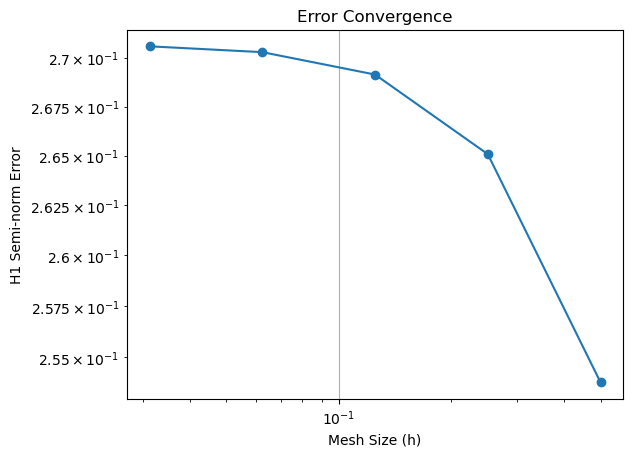

In [40]:

import numpy as np
import matplotlib.pyplot as plt

def compute_H1_seminorm_error(U, U_exact, A):
    """ Compute the H1 semi-norm error between the FEM and exact solutions. """
    difference = U_exact - U
    error_squared = np.dot(difference, A.dot(difference))
    return np.sqrt(error_squared)

def exact_solution(x1, x2):
    """ Define the exact solution for the given PDE. """
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

def source_term(x1, x2):
    """ Define the source term (RHS) of the PDE. """
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))

# Initialization of mesh and elements should be done before this script block
errors = []
mesh_sizes = []

for j in range(2, 7):
    Uhat, nodes, elements, N0 = run_simulation(j - 1, initial_nodes, initial_elements)  # Get updated N0
    U_exact = np.array([exact_solution(node[0], node[1]) for node in nodes[N0]])  # Use updated N0
    
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    A = Ahat[N0][:, N0]  # Use A corresponding to non-boundary nodes
    
    f = rhs(source_term, N0, elements, nodes)  # RHS using updated N0
    U = spsolve(A, f)  # Solve the system
    
    error = compute_H1_seminorm_error(U, U_exact, A)
    errors.append(error)
    h = 1 / (2 ** (j - 1))
    mesh_sizes.append(h)


# Print the results in a formatted table
print("Refinement Level | Mesh Size | H1 Semi-norm Error")
print("------------------------------------------------")
for i in range(len(errors)):
    print(f"{i + 2:16} | {mesh_sizes[i]:10} | {errors[i]:18.6f}")

# Optional: Plot the error vs. mesh size on a log-log plot to visualize convergence
plt.figure()
plt.loglog(mesh_sizes, errors, '-o')
plt.xlabel('Mesh Size (h)')
plt.ylabel('H1 Semi-norm Error')
plt.title('Error Convergence')
plt.grid(True)
plt.show()


In [50]:
def run_simulation(num_refinements, initial_nodes, initial_elements):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)  # Check the output of refine
        print(f"Refinement {i+1}, Number of Nodes: {len(nodes)}, Number of Elements: {len(elements)}")
    N0 = np.where(nodes[:, 2] != 1)[0]  # Non-boundary nodes
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    A = Ahat[N0][:, N0]
    f = rhs(source_term, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    return Uhat, nodes, elements, N0

# Example usage
Uhat, nodes, elements, N0 = run_simulation(4, initial_nodes, initial_elements)
U_exact = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Point-wise error at specific nodes
errors_at_nodes = np.abs(Uhat[N0] - U_exact[N0])
print("Errors at Non-Boundary Nodes:", errors_at_nodes)

# Checking error reduction at a specific node across refinements
specific_node_errors = []
for j in range(2, 7):
    Uhat, nodes, elements, N0 = run_simulation(j - 1, initial_nodes, initial_elements)
    U_exact = np.array([exact_solution(node[0], node[1]) for node in nodes])
    specific_node_index = 4  # Example: check an interior node
    specific_node_error = np.abs(Uhat[specific_node_index] - U_exact[specific_node_index])
    specific_node_errors.append(specific_node_error)
    print(f"Error at node index {specific_node_index} for refinement level {j}: {specific_node_error}")


Refinement 1, Number of Nodes: 13, Number of Elements: 16
Refinement 2, Number of Nodes: 41, Number of Elements: 64
Refinement 3, Number of Nodes: 145, Number of Elements: 256
Refinement 4, Number of Nodes: 545, Number of Elements: 1024
Errors at Non-Boundary Nodes: [0.08904657 0.04281602 0.09083893 0.03229415 0.07102371 0.05806044
 0.04222073 0.01278271 0.04129476 0.10841137 0.0835238  0.0736943
 0.02371653 0.0509434  0.02511634 0.00895734 0.06226546 0.04148746
 0.06380351 0.02907858 0.03122253 0.09270542 0.07184606 0.10548274
 0.06884063 0.02847136 0.0154926  0.03083007 0.03231652 0.06913864
 0.05622566 0.07875024 0.02766039 0.01919924 0.011412   0.00338236
 0.04650531 0.02660579 0.02600881 0.0990005  0.08258767 0.09558114
 0.1030341  0.08428491 0.0934027  0.10435995 0.05922326 0.06557043
 0.0373988  0.03895707 0.02617056 0.01285951 0.01303966 0.04488072
 0.03072934 0.03532019 0.05026763 0.01144854 0.02057992 0.00815621
 0.01786793 0.01092306 0.00732819 0.0023386  0.01924166 0.063348

After Refinement 3: Nodes = 145, Elements = 256
Ahat shape: (145, 145)
A shape: (113, 113)
LinAlgError: 0-dimensional array given. Array must be at least two-dimensional


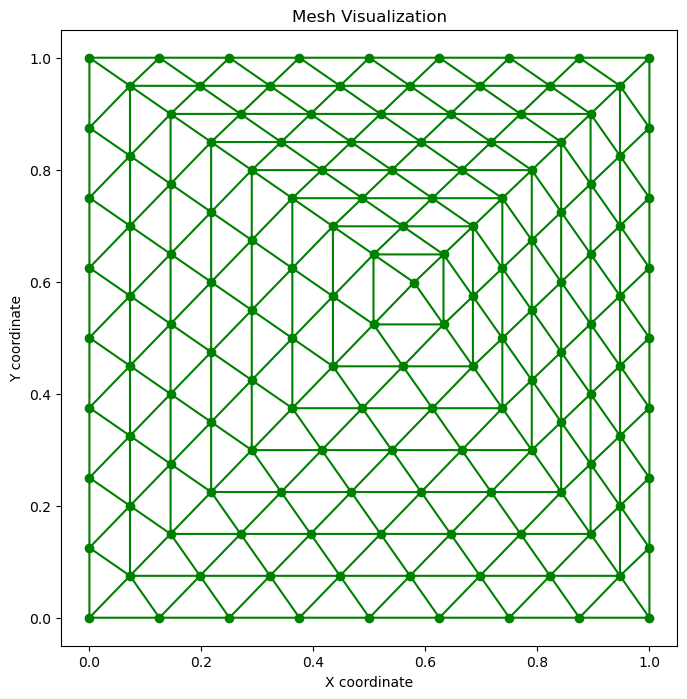

In [36]:
def run_simulation(num_refinements, initial_nodes, initial_elements):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)
    print(f"After Refinement {i+1}: Nodes = {len(nodes)}, Elements = {len(elements)}")
    N0 = np.where(nodes[:, 2] != 1)[0]  # Non-boundary nodes
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    print("Ahat shape:", Ahat.shape)  # Check the shape of Ahat
    A = Ahat[N0][:, N0]
    print("A shape:", A.shape)  # Check the shape of A
    if A.size == 0:
        print("Error: Matrix A is empty.")
        return None
    try:
        print(f"Matrix Size: {A.shape}, Condition Number: {np.linalg.cond(A)}")
    except np.linalg.LinAlgError as e:
        print(f"LinAlgError: {e}")
    f = rhs(source_term, N0, elements, nodes)
    U = spsolve(A, f)
    return U, nodes, elements, N0

# Example usage with debugging
try:
    U, nodes, elements, N0 = run_simulation(3, initial_nodes, initial_elements)
    if U is not None:
        plot_mesh(nodes, elements)  # Visual inspection of the mesh
except Exception as e:
    print(f"An error occurred: {e}")
